# C3 Boundary layer and GCI

## Introduction

We are going to simulate from scratch a well known a 2D airfoil. We 
will study the [NACA 65(1)-212 airfoil](https://en.wikipedia.org/wiki/NACA_airfoil#6-series), 
typically used for axial compressors and fans.

We will use the online platform [onShape](https://en.wikipedia.org/wiki/Onshape), a 3D CAD web-based software, which integrates very smoothly with Simscale. In this
way the work flow will be contained on the cloud, and we will not depend on local installed software or computer specifications.  OnShape is not free
but there is an [educational plan](https://www.onshape.com/en/education/).

The dynamics of fluid flow on an airfoil is produced mainly on the **boundary layer**. The correct size of the first cell adjacent to the airfoil is crucial for a reliable simulation.  This size is assessed using the $y^+$ dimensionless magnitude

$$ y^+ = \frac{y u_\tau}{\nu} \tag{1}$$

where $u_\tau = \sqrt{\frac{\tau}{\rho}}$, $y$ is the distance from cell center to airfoil, $\rho$ and $\nu$ are density and viscosity of air and $\tau$
is shear stress on the airfoil wall.





## Learning objectives

1. **Learn** to generate a 3D airfoil solid in **onShape** using coordinate data (CSV).
2. **Understand the concept** of **External Aerodynamics** and size the computational domain.
3. **Configure** local **Mesh Refinement** and boundary layer around the airfoil
4. **Size** grid on the wall to get a proper $y^+$ value
5. **Perform** Grid Convergence analysis for the simulation of flow around an airfoil 


## Previous tasks (about 2 hours)

- [ ] Create and educational account in Onshape 
- [ ] Become familiar with the platform by watching the video for [Onshape essentials webinar](https://learn.onshape.com/learn/video/onshape-essentials)
- [ ] (Optional) Take some tutorial or course from the Learning Center. For instance this [Fundamental course](https://learn.onshape.com/courses/introduction-to-part-studios)



## Making the geometry for the NACA 65(1)-212 airfoil

1. In you dashboard, create a new folder for this subject. For instance, `DFA`, or `Axial Fan`-
2. Make a new Document, named `NACA 65(1)-212`

![create.png](./images/C2_Create.png)

3. Import the CSV file for the airfoil. It is [here](./data/NACA65_1_212.csv). This imported file will be put in a tab of the project.

![import](./images/C2_import.png)

4. Add a `custom feature`. Look for the "Routing curve - Control Point Curve".

![Custom Feature](./images/C2_custom_feature.png)

5. Use this Custom Feature with the imported file (1). Click on "Proceed" (2) and the green button (3).

![RoutingCurve](./images/C2_RoutingCurve.png)

You will get something similar to that

![NACA_curve](./images/C2_Naca_curve.png)

6. `Transform` the curve to scale it for a 0.3 m chord.

![Trasnform](./images/C2_Transform.png)
![scale](./images/C2_Scale.png)

7. `Fill` the curve

![Fill](./images/C2_Fill.png)
![Filled](./images/C2_Filled.png)

8. And finally `Thicken` it 0.3 m to obtain a solid airfoil.

![Thicken](./images/C2_Thicken.png)
![Solid](./images/C2_Solid.png)

## Simulation of the airfoil



### Meshing

Now we are going to simulate the aerodynamic performance of this airfoil with Simscale

1. Sign-in in Simscale and create a `DFA` folder. Create a `New Project` in this folder. You can name it `NACA 65(1)-212`. The category should be `Machinery and Industrial Equipment`
2. The first think asked for is the `Geometry`. Click on "from Onshape` to connect with your account of the cloud service

![Geometry](./images/C2_CFD_geometry.png)

3. Navigate until the proper `Part` in the project. Import it

![Part](./images/C2_CFD_Part.png)

4. Open the geometry and Create the Simulation. Select an `Incompressible` kind with the default parameters (Turbulence model, steady steate...)

![CreateSimulation](./images/C2_CFD_CreateSimulation.png)

5. The first think will be the generation of the mesh. Click on the `Mesh` element, and select `Hex-dominant parametric` with the discretization shown in this picture. Save it. **Still don't generate** 

![Mesh1](./images/C2_CFD_Mesh1.png)

6. Open the `Background Mesh Box` element in the `Geometry primitives` section. Modify the dimensions according to this picture. In the upstream direction we
   get about 5 times the chord (1.5 m), and 15 times downstream (4.5 m), and 5 times the chord (1.5 m) in the top and bottom directions. In the $z$ direction we keep the airfoil dimensions. Save it.

![BMB](./images/C2_CFD_BMB.png) 

7. Be sure that the `Material Point` falls inside the fluid region (outside the airfoil)

![MP](./images/C2_CFD_MP.png)

8. We want to create a region around the airfoil where the mesh will be more refine. Create it by clicking on the `+` symbol in `Geometry primitives` and select `Cartesian box`. Give the dimensions of the figure and name it `Refinement box`. Save it.

![Refinement box](./images/C2_CFD_RefinementBox.png)

9. We define now the refinements. Click on `+` close to `Refinements` and select `Region refinement`. Raise the level to 4 and switch the selector close to `Refinement box`. Don't forget to save it

![levelBox](./images/C2_CFD_levelRefinementBox.png)

10. Add a `Refinement surface` with level 5 on the airfoil. Save it.

![RefinementSurface](./images/C2_CFD_RefinementSurface.png)

11.  Add an `Inflate Boundary Layer` on the airfoil surface. To compute the size of this boundary layer, some considerations have to be made. Depending on the value of $y^+$ (see Equation (1)), the turbulent boundary layer is divided in three regions:
   
   - **Viscous sublayer  $y^+ \lessapprox 5$**. Flow near the wall is dominated by viscosity and velocity profile is linear, $u^+ = \frac{u}{u_\tau} = y^+$.
   - **Buffer layer $5 \lessapprox y^+ \lessapprox 30$**. Both viscosity and turbulent shear stress are important. This region is mathematically highly complex and **should be avoided**.
   - **Log-law layer $30 \lessapprox y^+ \lessapprox 600$**. Turbulent shear dominates, and the velocity profile is log-like. The behavior of the flow and the dynamics on the wall is modelled with a **wall function**.

   ![LogLaw](./images/C2_Log_law.png)
   Image from [Wikipedia](https://en.wikipedia.org/wiki/Law_of_the_wall)

   If we want to save computational resources it is better to use wall functions on the airfoil and try to keep $y^+ > 30$. To do this, we have to
   estimate the size of the first cell on the airfoil wall. It is done with equation (1), computing $y$ in terms of $y^+$.
   
   $$ y = \frac{y^+ \nu}{u_\tau} = y^+ \nu \sqrt{\frac{\rho}{\tau}} $$

   That yields 

   $$ y > 30 \nu \sqrt{\frac{\rho}{\tau}} $$

   The shear stress $\tau$ can be estimated from the theory for turbulent boundary layer in a flat plate (see this [web page](https://www.cfd-online.com/Wiki/Skin_friction_coefficient))

   $$ \tau \approx \frac{0.058}{\textrm{Re}_c^{0.2}} $$

   where $\textrm{Re}_c = \frac{U_\infty c}{nu}$. We will see below that, in this case, $\textrm{Re}_c \approx 6\times10^5$, and the first cell center should be at an approximate distance of 0.5 mm to the wall. So, the height of the first cell should be about 1 mm. The following configuration 
   gets this size



![BoundaryLayer](./images/C2_CFD_BoundaryLayer.png)

12.  Back to the `Mesh`, it can now be generated.

![GenerateMesh](./images/C2_CFD_GenerateMesh.png)


It will take a while. In the meantime, read the [Simscale documentation about hex-dominant meshes](https://www.simscale.com/docs/simulation-setup/meshing/hex-dominant/).

After about 5-10 minutes, the mesh, with about 2 Million cells, will be ready for the simulation.

![Mesh Global](./images/C2_CFD_MeshGlobal.png)
![Mesh Detail](./images/C2_CFD_MeshDetail.png)

Since we have defined the mesh before the simulation parameters, the program propose to use the mesh as domain. Click on the proposal, and accept the reassignments of properties. Save it.

![Mesh as Domain](./images/C2_CFD_MeshAsDomain.png)

### Setup of the simulation

We want to compute the aerodynamic force and force coefficients fo this airfoil for several incidence angle. These will be the simulation data:

- Air velocity: $U = 30 \,\text{m/s}$
- Chord length: $c = 0.3\,\text{m}$
- Incidence angle: $\alpha = 4^{\circ}$
  

1. Define the material (fluid). It will be `air`. Keep the default properties. We annotate it for future use in the Notebook 

In [1]:
rho = 1.196  # density of air in kg/m^3
nu = 1.529e-5  # kinematic viscosity of air in m^2/s

2. For the initial condition, we keep $P = 0\,\text{Pa}$, but velocity will depend on the incidence angle (we modify the air direction, not the mesh). We define in `resources/utils.py` two python functions that:
   - Compute Reynolds number
   - Decompose velocity in $x$ and $y$ directions

In [2]:
from resources.utils import *

U = 30 # velocity in m/s
c = 0.3 # chord length in m
alpha = 4 # angle of attack in degrees

Re = ReynoldsNumber(U, c, nu)
u, v = velocityComponents(U, alpha)

Reynolds number: Re = 5.89e+05
Velocity components: u = 29.927 m/s, v = 2.093 m/s


Define the initial velocity for $\alpha = 4^\circ$, $U_x = 30 \, \text{m/s}$ and $U_y = 0 \, \text{m/s}$. Leave $k$ and $\omega$ (turbulence variables) with ts default values

3. We define the boundary conditions
   1. Define a `Custom - Freestream` boundary condition for the external surfaces in $x$ and $y$ directions.

![Free Stream](./images/C2_CFD_FreeStream.png)

4. Define a `Wall` boundary condition on the airfoil. Rename it `Airfoil`. 

![Wall](./images/C2_CFD_Wall.png)

5. Define a `Symmetry` boundary conditions for the front a back surfaces.

![Symmetry](./images/C2_CFD_symmetry.png)  

6. Define the monitor for aerodynamic forces in `Result control - Forces and Moments`. Assign the airfoil surface.

![Forces and Moments](./images/C2_CFD_ForcesMoments.png)

7. Define the Field Calculation for $y^+$ in `Result control - Field Calculations - Turbulence 1`. 

### Running the simulation

Create a new run, named `alpha_4`, and run it. Results will be ready in about 20 minutes.

### Post-processing

Value of $y^+$ can be inspected in the airfoil to check that it keeps below 30

![yPlus](./images/C2_yPlus.png)

Note: I have not found a way to plot in simscale the value of $y^+$ along the top and bottom surfaces. It would be possible to do that by downloading the case and using [paraview](https://www.paraview.org/)

Forces can be plotted and saved as a `CSV` file.

![Forces CSV](./images/C2_CFD_Forces_csv.png)

For this notebook it has been saved as `./data/C2_forces_4.csv`

In the same `resources/utils.py` file there is a function `get_forces_from_csv('file')` that gets the data and returns average value and standard deviations using the last iterations, to avoid transient initial behavior.

In [3]:
Fx_4, Fy_4, Fx_err_4, Fy_err_4 = get_forces_from_csv('./data/C2_forces_4.csv')

Mean forces: Fx = -0.55 N, Fy = 25.29 N
Standard deviation of forces: Fx_err = 0.0018 N, Fy_err = 0.0036 N


The function `LiftDragCoefficients(Fx,Fy,Fx_err,Fy_err,U,rho,c,b,alpha)` returns the lift and drag coefficients from the $x$ and $y$ forces. The width
of the profile is also needed to compute the surface

In [4]:
b = 0.3 # span length in m

Cl_4, Cd_4, Cl_err_4, Cd_err_4 = LiftDragCoefficients(Fx=Fx_4,Fy=Fy_4,Fx_err=Fx_err_4,Fy_err=Fy_err_4,U=U,rho=rho,c=c,b=b,alpha=alpha)

Lift: L = 25.26 +/- 0.08 N
Drag: D = 1.22 +/- 0.00 N
Lift coefficient: Cl = 0.5216 +/- 0.0017
Drag coefficient: Cd = 0.0252 +/- 0.0001


## Grid Convergence Study. Mesh sensitivity

Results from a CFD simulation should be independent of the spatial discretization. But in real world, with limited computational resources, it is not.
We are going to make a sensitivity study of results with the mesh by simulating with two more meshes: one coarser and another finer.

Details on the presented method, based on Richardson's extrapolation, can be consulted on the [book by Roache](https://discovery.upc.edu/permalink/34CSUC_UPC/i7glq6/alma991002514249706711):

  ROACHE, P.J., 1998. Verification and validation in computational science and engineering. Albuquerque, New Mexico: Hermosa. ISBN 0913478083. 

and also on the [web page by the NASA](https://www.grc.nasa.gov/WWW/wind/valid/tutorial/spatconv.html).

We will use the python package [convergence](https://github.com/Data-Only-Greater/convergence) to perform the computation of the discretization error.


### Construction of alternative meshes

The first step is to create two meshes with different discretization. The easier way in Simscale with hex-dominant parametric method is just 
modifying the `Bounding box resolution`. 

Make a coarser mesh with size 56 and 28 instead of 80 and 40, using the option `Create new mesh using settings from ...`. Call it `Mesh_coarse`.

![Mesh_coarse](./images/C2_CFD_Mesh_coarse.png)

Repeat the process for a new mesh `Mesh_fine` with resolution 112 and 56.

### New simulations

Make a new run (`alpha_4_coarse`) with this coarser mesh. Fluid domain, boundary conditions and surface for force and moment calculations have to be defined again.

Forces for this new simulation have been saved in the `./data/C2_forces_4_coarse.csv` file. 

Make a new run `alpha_4_fine` with the finer mesh and save the forces on `./data/C2_forces_4_fine.csv`

This are the results for the new simulations:

In [7]:
Fx_4_coarse, Fy_4_coarse, Fx_err_4_coarse, Fy_err_4_coarse = get_forces_from_csv('./data/C2_forces_4_coarse.csv')
Cl_4_coarse, Cd_4_coarse, Cl_err_4_coarse, Cd_err_4_coarse = LiftDragCoefficients(Fx=Fx_4_coarse,Fy=Fy_4_coarse,Fx_err=Fx_err_4_coarse,Fy_err=Fy_err_4_coarse,U=U,rho=rho,c=c,b=b,alpha=alpha)

Mean forces: Fx = -0.44 N, Fy = 24.76 N
Standard deviation of forces: Fx_err = 0.00064 N, Fy_err = 0.0073 N
Lift: L = 24.73 +/- 0.04 N
Drag: D = 1.29 +/- 0.00 N
Lift coefficient: Cl = 0.5106 +/- 0.0008
Drag coefficient: Cd = 0.0267 +/- 0.0000


In [8]:
Fx_4_fine, Fy_4_fine, Fx_err_4_fine, Fy_err_4_fine = get_forces_from_csv('./data/C2_forces_4_fine.csv')
Cl_4_fine, Cd_4_fine, Cl_err_4_fine, Cd_err_4_fine = LiftDragCoefficients(Fx=Fx_4_fine,Fy=Fy_4_fine,Fx_err=Fx_err_4_fine,Fy_err=Fy_err_4_fine,U=U,rho=rho,c=c,b=b,alpha=alpha)

Mean forces: Fx = -0.66 N, Fy = 25.42 N
Standard deviation of forces: Fx_err = 0.015 N, Fy_err = 0.003 N
Lift: L = 25.40 +/- 0.59 N
Drag: D = 1.12 +/- 0.03 N
Lift coefficient: Cl = 0.5244 +/- 0.0122
Drag coefficient: Cd = 0.0230 +/- 0.0005


Note the progression on the results. When mesh resolution is increased $C_l$ also increases, but $C_d$ decreases. They should tend to an asymptotic value
when resolutions approaches infinity.

### Computation of asymptotic values and GCI

We need a measure of average relative cell size. Consider that $h = 1$ is the average size of the medium mesh (the original one). Although the mesh is 3D, 
actually the simulation is 2D (the boundaries in the $z$ direction are `symmetry`) and the modification on the discretization has been made only on the $x$
and the $y$ directions. The number of `2D` cells is given by the number of face on the $z$ boundary, reported by the mesh log

![faces medium mesh](./images/C2_CFD_faces_medium.png)

The relative size of the coarse mesh will be computed with

$$ h_\text{coarse} = \sqrt{\frac{N_\text{coarse}}{N_\text{medium}}} $$

and, for the fine mesh

$$ h_\text{fine} = \sqrt{\frac{N_\text{fine}}{N_\text{medium}}} $$

In [15]:
N_coarse = 59730
N_medium = 118289
N_fine = 222595
h_coarse = np.sqrt(N_medium/N_coarse)
h_medium = 1.0
h_fine = np.sqrt(N_medium/N_fine)
print(f"Grid sizes: h_coarse = {h_coarse:.4f}, h_medium = {h_medium:.4f}, h_fine = {h_fine:.4f}")

Grid sizes: h_coarse = 1.4073, h_medium = 1.0000, h_fine = 0.7290


Now, we can compute the Grid Convergence Index (GCI) for both lift and drag coefficients using the coarse, medium, and fine grid results. The GCI provides a measure of the uncertainty due to grid resolution in numerical simulations.

In [17]:
from convergence import Convergence
grids_lift = [(h_coarse, Cl_4_coarse),
              (h_medium, Cl_4),
              (h_fine, Cl_4_fine)]
convergence_lift = Convergence()
convergence_lift.add_grids(grids_lift)
print(convergence_lift)



Number of grids to be examined = 3 

     Grid Size     Quantity 

     0.728978      0.524376 
     1.000000      0.521585 
     1.407265      0.510633 


Discretisation errors for fine grids: 

       Grids |     e_approx |     e_extrap |      f_exact |   gci_coarse | 
       1 2 3 |     0.005322 |     0.002194 |     0.525529 |     0.009401 | 
 ------------------------------------------------------------------------- 

       Grids |     gci_fine |            p |          r21 |          r32 | 
       1 2 3 |     0.002749 |     3.889831 |     1.371783 |     1.407265 | 
 ------------------------------------------------------------------------- 


Discretisation errors for coarse grids: 

       Grids |     e_approx |     e_extrap |      f_exact |   gci_coarse | 
       1 2 3 |     0.020998 |     0.007504 |     0.525529 |     0.035699 | 
 ------------------------------------------------------------------------- 

       Grids |     gci_fine |            p |          r21 |          r32 

The object `convergence` has all the information about the computation. In particular, `p` is the aparent order of the simulation and `f_exact` is the asymptotic theoretical value expected for a infinity large grid. An asymptotic ratio close to 1 indicates a very good convergence. We can plot it

In [38]:
# We compute first the Richardson extrapolation for the lift coefficient
Cl_fine = convergence_lift[0].values[0]
Cl_exact = convergence_lift[0].fine.f_exact
h_fine = convergence_lift[0].sizes[0]
p = convergence_lift[0].fine.p
B = (Cl_fine - Cl_exact) / (h_fine**p)
h_fit = np.linspace(0, 1.5, 100)
Cl_fit = Cl_exact + B*h_fit**p


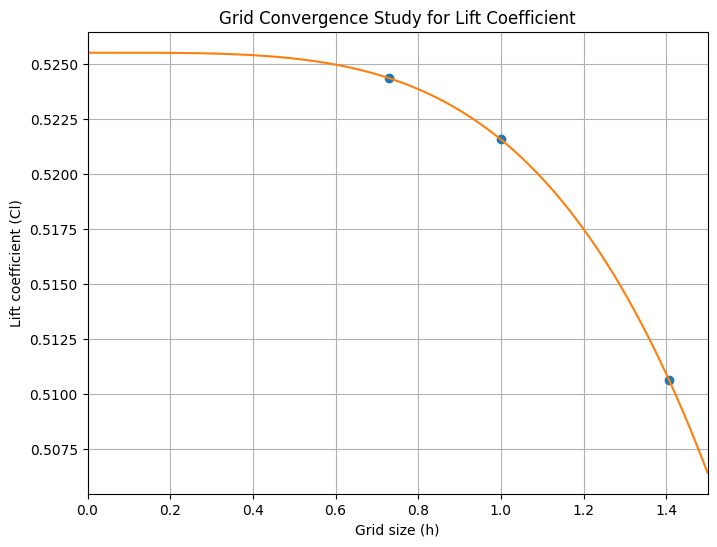

In [39]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(convergence_lift[0].sizes, convergence_lift[0].values, 'o', label='Lift coefficient')
ax.set_xlim([0, 1.5])
ax.plot(h_fit, Cl_fit, '-', label='Richardson extrapolation')
ax.set_xlabel('Grid size (h)')
ax.set_ylabel('Lift coefficient (Cl)')
ax.set_title('Grid Convergence Study for Lift Coefficient')
ax.grid(True)
plt.show()

And we can repeat the process for the drag coefficient.

In [40]:
from convergence import Convergence
grids_drag = [(h_coarse, Cd_4_coarse),
              (h_medium, Cd_4),
              (h_fine, Cd_4_fine)]
convergence_drag = Convergence()
convergence_drag.add_grids(grids_drag)
print(convergence_drag)


Number of grids to be examined = 3 

     Grid Size     Quantity 

     0.728978      0.023019 
     1.000000      0.025166 
     1.407265      0.026676 


Discretisation errors for fine grids: 

       Grids |     e_approx |     e_extrap |      f_exact |   gci_coarse | 
       1 2 3 |     0.093275 |     0.196922 |     0.019232 |     0.322247 | 
 ------------------------------------------------------------------------- 

       Grids |     gci_fine |            p |          r21 |          r32 | 
       1 2 3 |     0.205654 |     1.420775 |     1.371783 |     1.407265 | 
 ------------------------------------------------------------------------- 


Discretisation errors for coarse grids: 

       Grids |     e_approx |     e_extrap |      f_exact |   gci_coarse | 
       1 2 3 |     0.060007 |     0.106240 |     0.022749 |     0.195055 | 
 ------------------------------------------------------------------------- 

       Grids |     gci_fine |            p |          r21 |          r32 

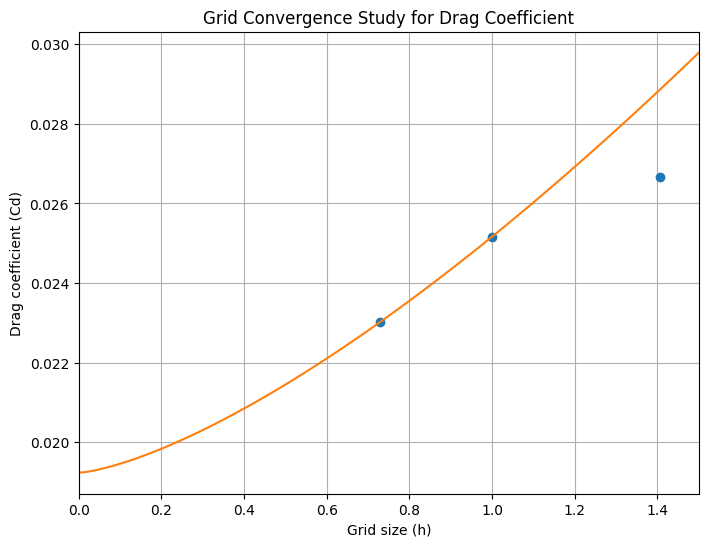

In [42]:
# We compute first the Richardson extrapolation for the drag coefficient
Cd_fine = convergence_drag[0].values[0]
Cd_exact = convergence_drag[0].fine.f_exact
h_fine = convergence_drag[0].sizes[0]
p = convergence_drag[0].fine.p
B = (Cd_fine - Cd_exact) / (h_fine**p)
h_fit = np.linspace(0, 1.5, 100)
Cd_fit = Cd_exact + B*h_fit**p

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(convergence_drag[0].sizes, convergence_drag[0].values, 'o', label='Drag coefficient')
ax.set_xlim([0, 1.5])
ax.plot(h_fit, Cd_fit, '-', label='Richardson extrapolation')
ax.set_xlabel('Grid size (h)')
ax.set_ylabel('Drag coefficient (Cd)')
ax.set_title('Grid Convergence Study for Drag Coefficient')
ax.grid(True)
plt.show()

## Some questions

Why do you think that we need to extend the Background Boundary domain so much as 15 times the chord length in the downstream direction? What issue would we find if we
place this boundary too close to the trailing edge?

***

Describe in your words the role of the Reynolds number. Take a look at the [data base for this airfoil](http://airfoiltools.com/airfoil/details?airfoil=naca651212-il#polars). The Reynolds number has a great influence on the airfoil performance.

***

Make an estimation about how large would be the mesh to get on the airfoil a $y^+ \approx 1$.

***

Results agree quite well with airfoiltool for drag coefficient but not so good as for lift. What do you think is the reason for that?

***

